# 👩‍💻 HR Attrition Prediction with Decision Trees and Random Forests

## 📋 Overview
In this lab, you'll use decision trees and random forests to predict employee attrition based on HR analytics data. You'll build and compare these models, then identify the key factors contributing to attrition. This will show how tree-based algorithms can help human resources understand and improve employee retention.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- In this lab, you'll clean and prepare HR attrition data for machine learning. 
- You'll then use decision trees and random forests to predict attrition, evaluating and comparing their performance. 
- Finally, you'll analyze feature importance to identify key indicators driving employee satisfaction, interpreting these insights within an organization context. 
- This will show how tree-based algorithms can be applied to identify risk factors and potentially improve employee outcomes.

## 🚀 Starting Point
Start with the provided starter code which includes necessary imports and data loading functionality:


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully.")
print("Shape of Dataset: ", df.shape)
print("First 5 records:")
df.head()

Dataset loaded successfully.
Shape of Dataset:  (1470, 35)
First 5 records:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## Task 1: Data Exploration
**Context:** Before building any machine learning model, it's essential to understand the dataset structure and characteristics, especially in the HR department where data quality directly impacts company outcomes.

**Steps:**

1. Display the first few rows of the dataset using `head()` to understand its structure
2. Examine the statistical summary of the data using `describe()`
3. Check for missing values using the `isnull().sum()` method
4. Explore the balance of the target variable (Consider Attrition as the target variable)


In [2]:
# Your data exploration code here
print("Dataset Information")
print(df.info())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobL

In [3]:
print("Summary of Data")
display(df.describe(percentiles=[.1, .2, .25, .5, .75, .9, .95, 1]).T)

Summary of Data


,count,mean,std,min,10%,20%,25%,50%,75%,90%,95%,100%,max
Age,1470.0,36.923810,9.135373,18.0,26.0,29.0,30.00,36.0,43.00,50.0,54.00,60.0,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,242.8,391.8,465.00,802.0,1157.00,1356.0,1424.10,1499.0,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,1.0,2.0,2.00,7.0,14.00,23.0,26.00,29.0,29.0
Education,1470.0,2.912925,1.024165,1.0,1.0,2.0,2.00,3.0,4.00,4.0,4.00,5.0,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.0,1.0,1.00,1.0,1.00,1.0,1.00,1.0,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,198.9,402.6,491.25,1020.5,1555.75,1857.1,1967.55,2068.0,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,1.0,2.0,2.00,3.0,4.00,4.0,4.00,4.0,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,38.0,45.0,48.00,66.0,83.75,94.0,97.00,100.0,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.0,2.0,2.00,3.0,3.00,3.0,4.00,4.0,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,1.0,1.00,2.0,3.00,4.0,4.00,5.0,5.0


In [4]:
print("Value Counts of Target Column")
print(df['Attrition'].value_counts(dropna=False))
print(df['Attrition'].value_counts(dropna=False, normalize=True))

Value Counts of Target Column
No     1233
Yes     237
Name: Attrition, dtype: int64
No     0.838776
Yes    0.161224
Name: Attrition, dtype: float64


In [5]:
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurre

**💡 Tip:** Pay special attention to the distribution of the target variable to determine if your dataset is balanced or imbalanced, as this will impact your model evaluation approach.

**⚙️ Test Your Work:**

- Execute your data exploration code and verify you can answer: How many features are in the dataset? Are there any missing values?


## Task 2: Data Cleaning and Preparation
**Context:** HR datasets often contain missing values or require feature engineering. Proper preprocessing ensures your model makes accurate predictions.

**Steps:**

1. Handle any missing values in the dataset (if present)
2. Handle categorical features, if any (e.g., using one-hot encoding with pandas.get_dummies)
3. Select relevant features for your model (This is important, try to check if you can find some features that are not relevant or have no explanatory power).
4. Separate features (X) and target variable (y)
5. Split the data into training and testing sets using `train_test_split()`

In [6]:
# Your data cleaning and preparation code here
df = df.fillna(method='ffill')

# Define target and features
X = df.drop(columns=['Attrition', 'EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])  # assuming 'Attrition' was one-hot encoded
y = df['Attrition']

# One-hot encode categorical columns
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (1029, 44)
X_test shape: (441, 44)
y_train shape: (1029,)
y_test shape: (441,)


**💡 Tip:** For HR data, carefully consider how to handle missing values. Simple imputation with mean values might not always be appropriate depending on the HR context.

**⚙️ Test Your Work:**

Check the shape of your X_train, X_test, y_train, and y_test to confirm proper splitting


## Task 3: Decision Tree Model Implementation
**Context:** Decision trees provide an interpretable approach to explain attrition in this case, making them valuable in understanding the model's decision process is crucial.

**Steps:**

1. Initialize a DecisionTreeClassifier with appropriate parameters to prevent overfitting (consider setting `max_depth`)
2. Fit the model to your training data
3. Make predictions on the test set
4. Calculate the accuracy using `accuracy_score()`
5. Generate a classification report using `classification_report()`
6. Visualize the confusion matrix using `ConfusionMatrixDisplay`


Accuracy: 0.81
Classification Report:
               precision    recall  f1-score   support

          No       0.86      0.92      0.89       370
         Yes       0.37      0.25      0.30        71

    accuracy                           0.81       441
   macro avg       0.62      0.58      0.59       441
weighted avg       0.78      0.81      0.79       441



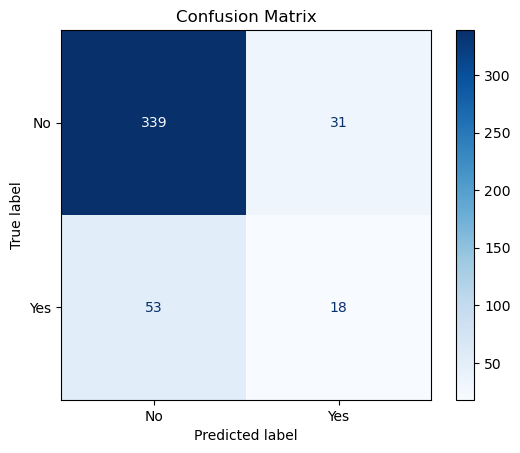

In [7]:
# Your decision tree implementation code here

# Initialize with max_depth to prevent overfitting
model_dt = DecisionTreeClassifier(max_depth=5, random_state=42)
model_dt.fit(X_train, y_train)


y_pred_dt = model_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:\n", classification_report(y_test, y_pred_dt))

ConfusionMatrixDisplay.from_estimator(model_dt, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

**💡 Tip:** Try different values of max_depth to find a balance between model complexity and accuracy.

**⚙️ Test Your Work:**

Your decision tree should output an accuracy score and display a confusion matrix


## Task 4: Random Forest Model Implementation
**Context:** Random Forest models often provide better predictive performance than single decision trees by reducing overfitting, which is crucial for reliable attrition risk prediction.

**Steps:**

1. Initialize a RandomForestClassifier with an appropriate number of estimators
2. Train the model on your training data
3. Generate predictions on the test set
4. Evaluate model performance using accuracy and a classification report
5. Create a confusion matrix visualization


Random Forest Accuracy: 0.83
Classification Report:
               precision    recall  f1-score   support

          No       0.85      0.97      0.91       370
         Yes       0.45      0.13      0.20        71

    accuracy                           0.83       441
   macro avg       0.65      0.55      0.55       441
weighted avg       0.79      0.83      0.79       441



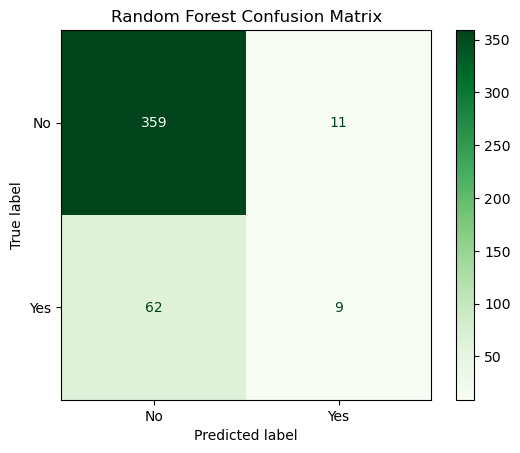

In [8]:
# Your random forest implementation code here
# Initialize with 100 trees (adjustable)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Initialize with 100 trees (adjustable)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.show()

**💡 Tip:** Random forests typically perform better with default parameters than decision trees, but you can still experiment with n_estimators and max_depth to optimize performance.

**⚙️ Test Your Work:**

Compare the accuracy of your random forest model with the decision tree model


## Task 5: Feature Importance Analysis
**Context:** Understanding which factors most strongly influence the attrition can guide the relevant teams to understand how to be pro-active to prevent attrition..

**Steps:**

1. Extract feature importance scores from your Random Forest model
2. Sort features by their importance
3. Create a bar plot visualizing the importance of each feature
4. Analyze which variables have the highest importance in terms of explaining the target variable.
5. Add a comparison between the two models.


In [9]:
# Your feature importance analysis code here
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from Random Forest
importances_rf = rf_model.feature_importances_
features = X_train.columns

# Create a DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

importance_df

,Feature,Importance
9,MonthlyIncome,0.078772
0,Age,0.064982
16,TotalWorkingYears,0.054929
1,DailyRate,0.051431
5,HourlyRate,0.049992
10,MonthlyRate,0.048017
19,YearsAtCompany,0.045208
2,DistanceFromHome,0.043131
22,YearsWithCurrManager,0.041797
43,OverTime_Yes,0.039565


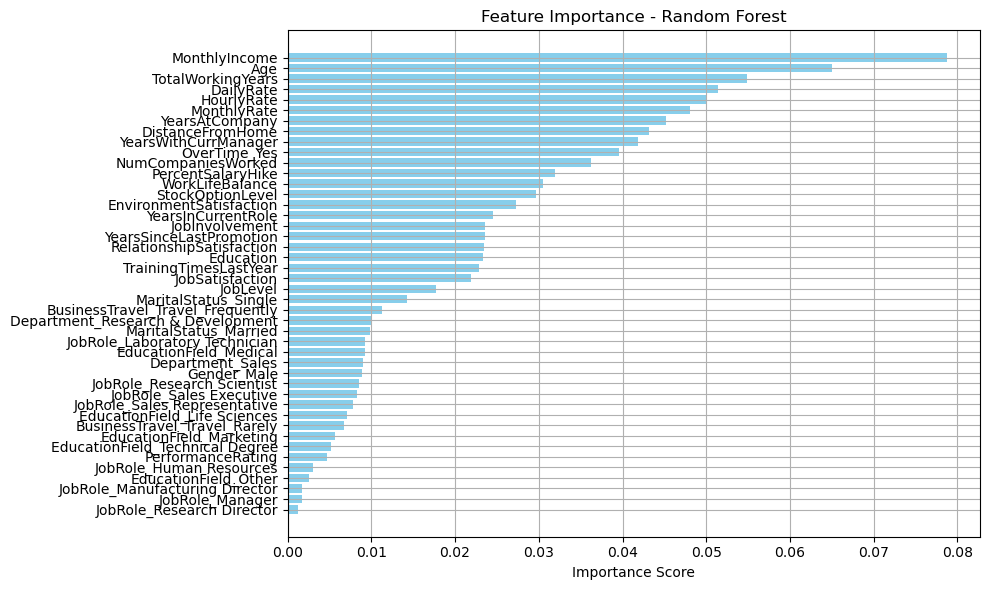

In [10]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
# Decision Tree feature importances
importances_dt = model_dt.feature_importances_

# Combine for comparison
comparison_df = pd.DataFrame({
    'Feature': features,
    'RandomForest': importances_rf,
    'DecisionTree': importances_dt,
}).set_index('Feature').sort_values(by='RandomForest', ascending=False)

comparison_df['Difference (RF-DT)']= comparison_df['RandomForest'] - comparison_df['DecisionTree']
print("Feature Importance Comparison")

comparison_df

Feature Importance Comparison


,RandomForest,DecisionTree,Difference (RF-DT)
Feature,,,
MonthlyIncome,0.078772,0.132543,-0.053772
Age,0.064982,0.108213,-0.043231
TotalWorkingYears,0.054929,0.209308,-0.154379
DailyRate,0.051431,0.073785,-0.022354
HourlyRate,0.049992,0.000000,0.049992
MonthlyRate,0.048017,0.000000,0.048017
YearsAtCompany,0.045208,0.000000,0.045208
DistanceFromHome,0.043131,0.031553,0.011579
YearsWithCurrManager,0.041797,0.000000,0.041797


In [12]:
from sklearn.metrics import accuracy_score

print("\n--- Model Comparison ---")
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

print("\n-- Insights --")
if rf_accuracy > dt_accuracy:
    print("✅ The Random Forest Classifier performed better than the Decision Tree in terms of accuracy.")
    print("This is often expected, as Random Forest is an ensemble method that combines multiple decision trees, reducing overfitting and improving generalization.")
elif dt_accuracy > rf_accuracy:
    print("🔍 In this particular run, the **Decision Tree Classifier** had slightly higher accuracy.")
    print("While less common, this can happen depending on the dataset characteristics or if the Random Forest hyperparameters aren't optimally tuned.")
else:
    print("⚖️ Both models achieved similar accuracy.")


--- Model Comparison ---
Decision Tree Accuracy: 0.8095
Random Forest Accuracy: 0.8345

-- Insights --
✅ The Random Forest Classifier performed better than the Decision Tree in terms of accuracy.
This is often expected, as Random Forest is an ensemble method that combines multiple decision trees, reducing overfitting and improving generalization.


**💡 Tip:** Connect the feature importance findings back to real-world HR implications.

**⚙️ Test Your Work:** Your visualization should clearly show which features have the highest importance scores

## ✅ Success Checklist
- Dataset is properly loaded and explored
- Data cleaning steps are implemented appropriately
- Decision Tree model is trained and evaluated
- Random Forest model is trained and compared to the Decision Tree
- Feature importances are extracted and visualized
- All visualizations are properly labeled and interpretable
- Program runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Low model accuracy 
- **Solution:** Try adjusting hyperparameters like max_depth for Decision Trees or n_estimators for Random Forests

**Problem:** Feature importance visualization is unclear 
- **Solution:** Sort features by importance and limit to top N features if you have many variables

## 🔑 Key Points
- Decision trees provide interpretable models but may suffer from overfitting
- Random forests typically offer better performance by averaging multiple decision trees
- Feature importance analysis provides valuable insights for this dataset but generally any dataset to understand how the outcomes are determined by the feature variables. This is an iterative process.
- Model evaluation should consider multiple metrics beyond just accuracy, especially for HR applications

## ➡️ Next Steps
In future labs, you'll explore more advanced ensemble methods and apply these techniques to more complex datasets. You'll also learn how to perform hyperparameter tuning to optimize your models further.


## Exemplar Solution
After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches. Reflect on what you can learn from the exemplar solution to improve your coding skills. Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches. Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>

<summary><strong>Click HERE to see an exemplar solution</strong></summary>    
    
```python
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Load the dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("Dataset loaded successfully.")
print("First 5 records:")
print(df.head())

print("\n--- Dataset Info ---")
print(df.info())

print("\n--- Dataset Description ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

# For this HR dataset, let's look at the target variable distribution
if 'Attrition' in df.columns:
    print("\n--- Attrition Distribution ---")
    print(df['Attrition'].value_counts())
    sns.countplot(x='Attrition', data=df)
    plt.title('Distribution of Attrition')
    plt.show()

# Identify features (X) and target (y)
# For the IBM HR Analytics dataset, 'Attrition' is the target variable.
# We'll drop 'EmployeeCount', 'StandardHours', 'Over18', and 'EmployeeNumber'
# as they are constant or unique identifiers with no predictive power.
if 'Attrition' in df.columns:
    y = df['Attrition']
    X = df.drop(['Attrition', 'EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'], axis=1, errors='ignore') # errors='ignore' prevents error if column already dropped
else:
    print("Error: 'Attrition' column not found. Please ensure the correct dataset is loaded.")
    # Fallback for dummy dataset
    X = df.drop('target', axis=1)
    y = df['target']
    print("Using dummy dataset for preprocessing.")


# Convert 'Attrition' target to numerical (Yes=1, No=0)
if y.dtype == 'object':
    y = y.map({'Yes': 1, 'No': 0})
    print("Converted 'Attrition' to numerical (Yes=1, No=0).")

# One-hot encode categorical features in X
X = pd.get_dummies(X, drop_first=True)
print("\n--- Features after One-Hot Encoding ---")
print(X.head())
print(f"Number of features after encoding: {X.shape[1]}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
# Using stratify=y helps maintain the same proportion of target classes in both train and test sets,
# which is important for imbalanced datasets like this one.

print(f"\nTraining set shape: {X_train.shape}, Test set shape: {X_test.shape}")

print("\n--- Running Decision Tree Classifier ---")
# Initialize and train the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# Evaluate the Decision Tree model
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("\n--- Running Random Forest Classifier ---")
# Initialize and train the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators is the number of trees
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the Random Forest model
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

# Feature Importance for Random Forest
print("\n--- Random Forest Feature Importance ---")
feature_importances = pd.Series(rf_classifier.feature_importances_, index=X.columns)
# Get top 10 features
top_10_features = feature_importances.nlargest(10)
print(top_10_features)

plt.figure(figsize=(12, 7))
top_10_features.sort_values(ascending=True).plot(kind='barh')
plt.title('Top 10 Random Forest Feature Importances')
plt.xlabel('Importance')
plt.show()

print("\n--- Model Comparison ---")
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")


print("--Insights--")

if rf_accuracy > dt_accuracy:
    print("\nThe **Random Forest Classifier** performed better than the Decision Tree in terms of accuracy.")
    print("This is often expected, as Random Forest is an ensemble method that combines multiple decision trees, reducing overfitting and improving generalization.")
elif dt_accuracy > rf_accuracy:
    print("\nIn this particular run, the **Decision Tree Classifier** had slightly higher accuracy.")
    print("While less common, this can happen depending on the dataset characteristics or if the Random Forest hyperparameters aren't optimally tuned.")
else:
    print("\nBoth models achieved similar accuracy.")

    
```